<a href="https://colab.research.google.com/github/abiud2emiliano-sudo/PPIA/blob/main/AF2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Actividad Fundamental 2- Regresion Lineal


In [3]:
# Importar librerías
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = pd.Series(california.target, name='MedHouseVal')
print("Variables independientes (X):")
display(X.head())
print("Variable dependiente (y):")
display(y.head())

Variables independientes (X):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Variable dependiente (y):


,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [4]:

import matplotlib.pyplot as plt
import seaborn as sns
df = X.copy()
df['MedHouseVal'] = y
print("Primeras 5 filas:")
display(df.head())
print("\nInformación general:")
print(df.info())
print("\nEstadísticas descriptivas:")
display(df.describe())

Primeras 5 filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Estadísticas descriptivas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


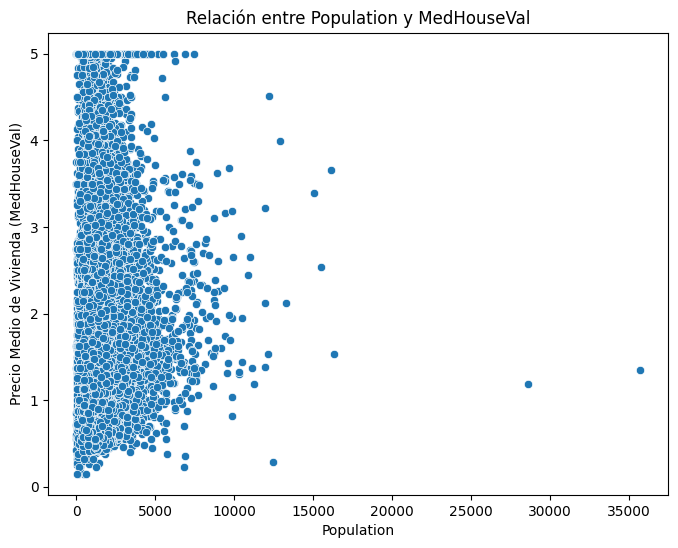

In [5]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Population'],
    y=df['MedHouseVal']
)
plt.title('Relación entre Population y MedHouseVal')
plt.xlabel('Population')
plt.ylabel('Precio Medio de Vivienda (MedHouseVal)')
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Datos escalados correctamente")
print("Tamaño entrenamiento:", X_train_scaled.shape)
print("Tamaño prueba:", X_test_scaled.shape)

Datos escalados correctamente
Tamaño entrenamiento: (16512, 8)
Tamaño prueba: (4128, 8)


In [7]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)
print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [8]:
# Realizar 3 predicciones
predicciones = modelo.predict(X_test_scaled[:3])

# Mostrar resultados
for i in range(3):
    print(f"Predicción {i+1}: {predicciones[i]:.4f}")
    print(f"Valor real     : {y_test.iloc[i]:.4f}")
    print("-"*30)

Predicción 1: 0.7191
Valor real     : 0.4770
------------------------------
Predicción 2: 1.7640
Valor real     : 0.4580
------------------------------
Predicción 3: 2.7097
Valor real     : 5.0000
------------------------------


In [9]:
# Importar métrica
from sklearn.metrics import mean_squared_error
# Predicciones completas
y_pred = modelo.predict(X_test_scaled)
# Calcular MSE
mse = mean_squared_error(y_test, y_pred)
# Mostrar resultado
print("Error Cuadrático Medio (MSE):", mse)

Error Cuadrático Medio (MSE): 0.5558915986952442
